1. IMPORTS

In [33]:
import pandas as pd
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt
import seaborn as sns

2. DATA LOADING

In [34]:
df = pd.read_csv("query3.csv")
df

,film,filmLabel,year,boxOffice,isAdaptation,period
0,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
1,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
2,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
3,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
4,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
...,...,...,...,...,...,...
15425,http://www.wikidata.org/entity/Q18406872,Doctor Strange,2016,677718395.0,1,After 2010
15426,http://www.wikidata.org/entity/Q18486021,Star Wars: Episode VIII – The Last Jedi,2017,620181382.0,0,After 2010
15427,http://www.wikidata.org/entity/Q18486021,Star Wars: Episode VIII – The Last Jedi,2017,620181382.0,0,After 2010
15428,http://www.wikidata.org/entity/Q18486021,Star Wars: Episode VIII – The Last Jedi,2017,620181382.0,0,After 2010


3. DATA CLEANING

In [35]:
# Remove duplicates
df = df.drop_duplicates(subset=['film'])
df

,film,filmLabel,year,boxOffice,isAdaptation,period
0,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
5,http://www.wikidata.org/entity/Q571309,Undertow,2004,143597.0,0,Before 2010
7,http://www.wikidata.org/entity/Q593123,My Winnipeg,2007,159363.0,0,Before 2010
12,http://www.wikidata.org/entity/Q813724,Becket,2007,149327.0,1,Before 2010
15,http://www.wikidata.org/entity/Q1053293,I Wish,2011,145808.0,0,After 2010
...,...,...,...,...,...,...
15390,http://www.wikidata.org/entity/Q4985891,X-Men: Days of Future Past,2014,746045700.0,1,After 2010
15397,http://www.wikidata.org/entity/Q11220194,Dawn of the Planet of the Apes,2014,710644566.0,1,After 2010
15405,http://www.wikidata.org/entity/Q11533494,The World of Kanako,2014,750000000.0,1,After 2010
15412,http://www.wikidata.org/entity/Q15401703,Drishyam,2013,750000000.0,0,After 2010


4. CREATION OF THE TIME VARIABLE

In [36]:
# df['period'] = np.where(df['year'] < 2010, "Before 2010", "After 2010")

5. DESCRIPTIVE STATISTICS

In [37]:
n_before = df[df['period']=="Before 2010"].shape[0]
n_after  = df[df['period']=="After 2010"].shape[0]

print(f"Before 2010: {n_before}, After 2010: {n_after}")

Before 2010: 1492, After 2010: 2085


6. Number of Adaptations and Observed Proportions

In [38]:
# Counts
k_before = df[(df['period']=="Before 2010") & (df['isAdaptation']==1)].shape[0]
k_after  = df[(df['period']=="After 2010") & (df['isAdaptation']==1)].shape[0]

print(f"Before: {k_before}/{n_before}")
print(f"After: {k_after}/{n_after}")

# Proportions
p_before = k_before / n_before
p_after  = k_after / n_after

print(f"p_before = {p_before:.3f}")
print(f"p_after  = {p_after:.3f}")

Before: 417/1492
After: 584/2085
p_before = 0.279
p_after  = 0.280


7. SUMMARY TABLE

In [39]:
results = pd.DataFrame({
    "Period": ["Before 2010", "After 2010"],
    "n (films)": [n_before, n_after],
    "k (adaptations)": [k_before, k_after],
    "Proportion": [p_before, p_after]
})

results

,Period,n (films),k (adaptations),Proportion
0,Before 2010,1492,417,0.279491
1,After 2010,2085,584,0.280096


8. BAYESIAN MODEL

In [40]:
# Prior
alpha0, beta0 = 1, 1

# Posterior parameters
a_before = alpha0 + k_before
b_before = beta0 + (n_before - k_before)

a_after = alpha0 + k_after
b_after = beta0 + (n_after - k_after)

# Means
mean_before = beta.mean(a_before, b_before)
mean_after  = beta.mean(a_after, b_after)

# Credible intervals
ci_before = beta.interval(0.95, a_before, b_before)
ci_after  = beta.interval(0.95, a_after, b_after)

print("Before:", mean_before, ci_before)
print("After:", mean_after, ci_after)

Before: 0.2797858099062918 (np.float64(0.25731481703243353), np.float64(0.302815236379466))
After: 0.2803066602779109 (np.float64(0.2612435965797637), np.float64(0.29976853975787826))


9. BAYESIAN COMPARISON BETWEEN PERIODS

In [41]:
# Monte Carlo Sampling
samples_before = np.random.beta(a_before, b_before, 100000)
samples_after  = np.random.beta(a_after, b_after, 100000)

# Posterior Difference
diff = samples_after - samples_before

# Probability of Increase
prob = np.mean(diff > 0)

# Credible Interval
ci_diff = np.quantile(diff, [0.025, 0.975])

print(f"P(after > before) = {prob:.3f}")
print(f"CI difference = {ci_diff}")

P(after > before) = 0.512
CI difference = [-0.02952955  0.03023255]


10. VISUALISATION OF RESULTS

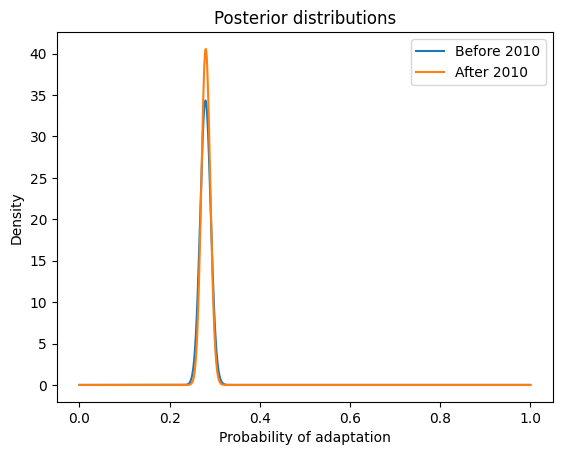

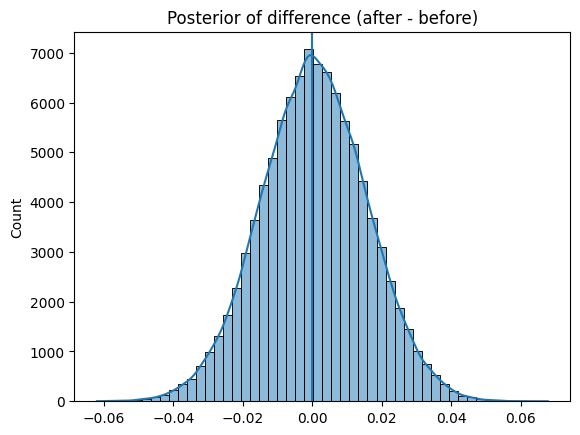

In [42]:
# Posterior distributions
x = np.linspace(0, 1, 1000)

plt.figure()
plt.plot(x, beta.pdf(x, a_before, b_before), label="Before 2010")
plt.plot(x, beta.pdf(x, a_after, b_after), label="After 2010")
plt.title("Posterior distributions")
plt.xlabel("Probability of adaptation")
plt.ylabel("Density")
plt.legend()
plt.show()

# Difference distribution
plt.figure()
sns.histplot(diff, bins=50, kde=True)
plt.axvline(0)
plt.title("Posterior of difference (after - before)")
plt.show()